# Compressing a pitch contour

A pitch contour is one value per frame on a uniform grid — cents of pitch, `nan` where the frame carries none. Held as it stands it costs eight bytes a frame; packed it costs less than one. The contour goes through the pipeline below one stage at a time: what each stage does to the data, how the data looks once it is done, and what it costs.

* **rounding** — to whole cents, with a reserved value for the frames without a pitch;
* **differences** — each frame minus the one before it, wrapped to sixteen bits;
* **zigzag** — signed values folded onto the non-negative axis, small magnitudes staying small;
* **variable-length integers** — seven bits a byte, so a small value costs a single byte;
* **deflate** — back-references and Huffman codes over the byte stream.

Every stage but the first reverses exactly, and the one loss anywhere in the pipeline is the rounding: half a cent at most, against a pitch grid fifty cents wide.

In [1]:
%matplotlib inline
import sys
import zlib
import yaml
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "config.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import librosa
import matplotlib.pyplot as plt
import numpy as np
from google.protobuf.internal.encoder import _VarintBytes
from google.protobuf.internal.wire_format import ZigZagDecode, ZigZagEncode

from helpers import plots, utils
from pitchtrack import (HEADER, cumulate, decode_contour, decode_varints, dequantise,
                        differences, encode_contour, encode_varints, quantise,
                        unzigzag, zigzag)

PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#F0E442", "#000000"]
plots.set_style(PALETTE)

DATA = ROOT / "data"

## The signal

Pitch extraction gives a frequency $f_i$ per frame. Measured against `app.ref_hz` in cents,

$$c_i = 1200 \log_2 \frac{f_i}{f_{ref}}$$

a frame with no pitch stays `nan`. This is the contour below: one `float64` a frame, eight bytes, most of whose precision the ear will never use.
Extraction runs finer than the app's grid: before packing, the contour is median-pooled — `nan` ignored — onto `app.hop_seconds` in `config.yaml`, so one frame below is one step of that grid.

In [2]:
EXAMPLE = DATA / "queries" / "q1.mp3"
CONFIG = yaml.safe_load((ROOT / "config.yaml").read_text())
PITCH = CONFIG["notebook"]

y, sr = librosa.load(EXAMPLE, sr=PITCH["sr"], mono=True)
hop_length = round(PITCH["hop_seconds"] * sr)
f0, voiced_flag, _ = librosa.pyin(
    np.asarray(y, dtype=np.float64),
    fmin=PITCH["fmin"],
    fmax=PITCH["fmax"],
    sr=sr,
    frame_length=PITCH["frame_length"],
    hop_length=hop_length,
)
f0 = np.where(voiced_flag, f0, np.nan)

hop_seconds = hop_length / sr
contour = 1200.0 * np.log2(f0 / 55.0)
contour = utils.downsample(contour, round(CONFIG["app"]["hop_seconds"] / hop_seconds))
hop_seconds = CONFIG["app"]["hop_seconds"]
seconds = np.arange(contour.size) * hop_seconds

voiced = np.flatnonzero(np.isfinite(contour))
window_start = int(voiced[voiced.size // 2]) if voiced.size else 0
window = slice(window_start, min(window_start + 12, contour.size))

print(EXAMPLE)
print(f"{contour.size} frames over {seconds[-1]:.1f} seconds, hop {hop_seconds:g} s")
print(f"{np.isnan(contour).sum()} frames carry no pitch")
print(f"{contour.nbytes} bytes of float64, {contour.nbytes / contour.size:g} bytes a frame")
print()
print(f"frames {window.start}..{window.stop - 1}")
print(f"{'frame':>5}  {'cents':>10}")
for frame in range(window.start, window.stop):
    print(f"{frame:5d}  {contour[frame]:10.3f}")

/home/vivekv/Desktop/Strawberry-Fields/data/queries/q1.mp3
157 frames over 15.6 seconds, hop 0.1 s
17 frames carry no pitch
1256 bytes of float64, 8 bytes a frame

frames 77..88
frame       cents
   77    2903.682
   78    2893.682
   79    2893.682
   80    2858.682
   81    2908.682
   82    2893.682
   83    2873.682
   84    2903.682
   85    2843.682
   86    2868.682
   87         nan
   88         nan


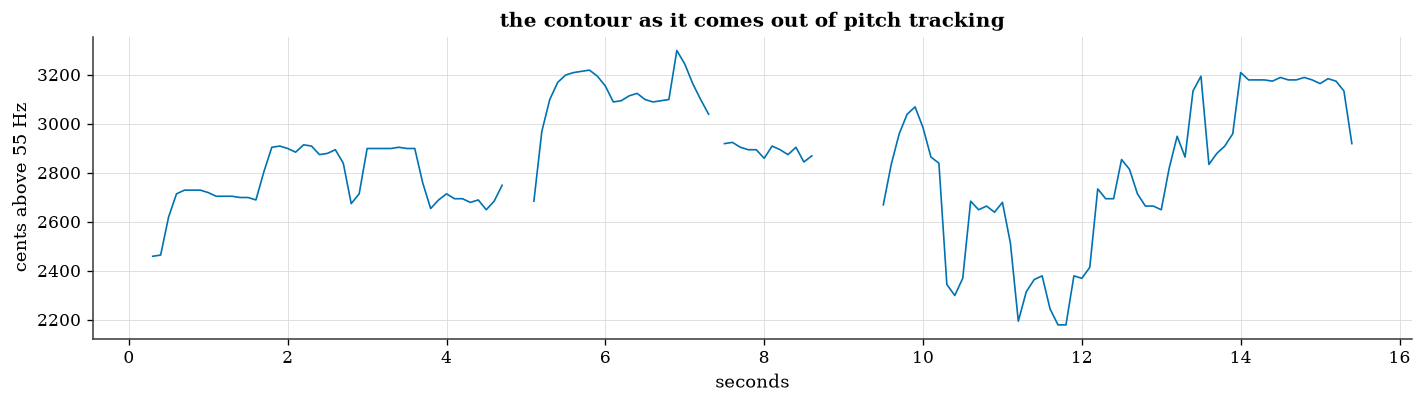

In [3]:
plt.figure(figsize=(12, 3.5))
plt.plot(seconds, contour, lw=1, color=PALETTE[0])
plt.xlabel("seconds")
plt.ylabel("cents above 55 Hz")
plt.title("the contour as it comes out of pitch tracking")
plt.tight_layout()

## Rounding

Each frame collapses to the nearest whole cent:

$$q_i = \mathrm{round}(c_i), \qquad |q_i - c_i| \le \tfrac12$$

half a cent against a grid whose notes sit fifty cents apart — a hundredth of the distance between two adjacent notes — so nothing audible is lost. A frame without a pitch becomes the reserved value $-32768$, the smallest value a 16-bit signed integer can hold: no real cent value can take it, so it reads back as `nan` rather than as a pitch. The contour now costs two bytes a frame instead of eight.

frame       cents  rounded     error
   77    2903.682     2904    +0.318
   78    2893.682     2894    +0.318
   79    2893.682     2894    +0.318
   80    2858.682     2859    +0.318
   81    2908.682     2909    +0.318
   82    2893.682     2894    +0.318
   83    2873.682     2874    +0.318
   84    2903.682     2904    +0.318
   85    2843.682     2844    +0.318
   86    2868.682     2869    +0.318
   87         nan      nan      +nan
   88         nan      nan      +nan

rounding error: max 0.318 cents, mean 0.318 cents
10.8% of frames carry no pitch, held as -32768 and read back as nan
size: 1256 -> 314 bytes (25%)


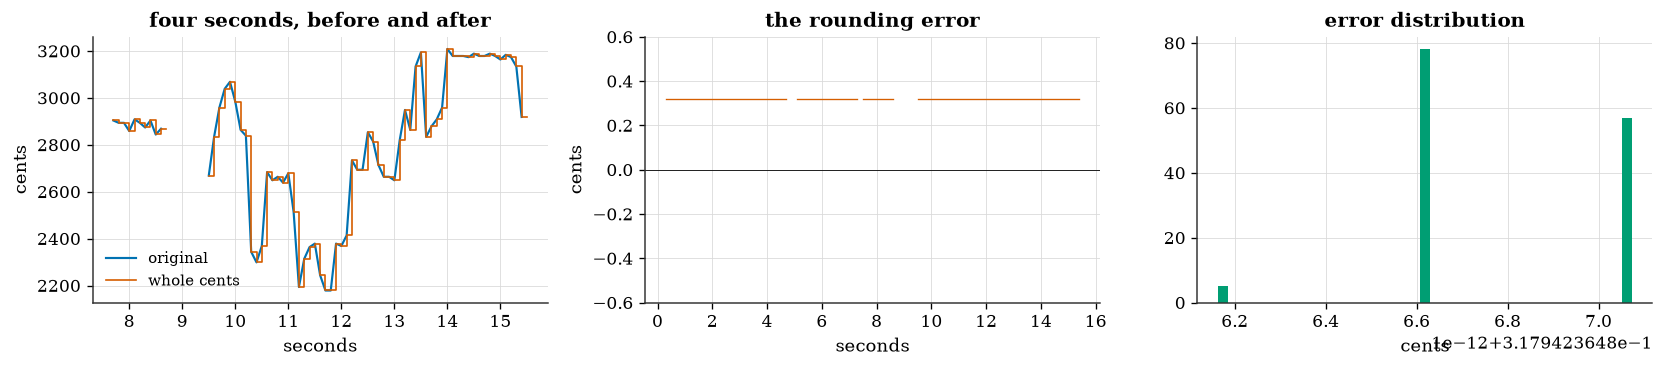

In [4]:
samples = quantise(contour)
quantised = dequantise(samples)
qerror = quantised - contour

print(f"{'frame':>5}  {'cents':>10}  {'rounded':>7}  {'error':>8}")
for frame in range(window.start, window.stop):
    print(f"{frame:5d}  {contour[frame]:10.3f}  {quantised[frame]:7.0f}  {qerror[frame]:+8.3f}")

unvoiced_share = np.mean(samples == np.iinfo(np.int16).min)
print()
print(f"rounding error: max {np.nanmax(np.abs(qerror)):.3f} cents, "
      f"mean {np.nanmean(np.abs(qerror)):.3f} cents")
print(f"{unvoiced_share:.1%} of frames carry no pitch, held as -32768 and read back as nan")
print(f"size: {contour.nbytes} -> {samples.nbytes} bytes ({samples.nbytes / contour.nbytes:.0%})")

zoom = slice(window_start, min(window_start + 160, contour.size))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2))
axes[0].plot(seconds[zoom], contour[zoom], lw=1.3, label="original")
axes[0].step(seconds[zoom], quantised[zoom], where="post", lw=1, label="whole cents")
axes[0].set_title("four seconds, before and after")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("cents")
axes[0].legend()

axes[1].plot(seconds, qerror, lw=0.8, color=PALETTE[1])
axes[1].axhline(0, lw=0.5, color="black")
axes[1].set_ylim(-0.6, 0.6)
axes[1].set_title("the rounding error")
axes[1].set_xlabel("seconds")
axes[1].set_ylabel("cents")

axes[2].hist(qerror[np.isfinite(qerror)], bins=41, color=PALETTE[2])
axes[2].set_title("error distribution")
axes[2].set_xlabel("cents")
plt.tight_layout()

## Differences

A contour drifts — consecutive frames sit a few cents apart — so what a frame *is* is largely an offset its neighbour already carries. Take the neighbour away:

$$d_0 = q_0, \qquad d_i = q_i - q_{i-1} \pmod{2^{16}}$$

read back in $[-2^{15}, 2^{15})$, so every difference still fits in the same two bytes. Nearly all of them collapse to a few cents around zero, with spikes only where voicing starts or stops. The contour comes back by addition alone:

$$q_i = \sum_{j \le i} d_j \pmod{2^{16}}$$

exactly — nothing here loses anything.

frame  rounded  difference
   77     2904         -20
   78     2894         -10
   79     2894           0
   80     2859         -35
   81     2909          50
   82     2894         -15
   83     2874         -20
   84     2904          30
   85     2844         -60
   86     2869          25
   87   -32768       29899
   88   -32768           0

median |difference|: 30 cents
35.7% of frames move ten cents or less
9 frames jump over a thousand cents: a voicing edge
first frame kept, the rest equal the wrapped difference: True
cumulating the differences rebuilds the cents: True


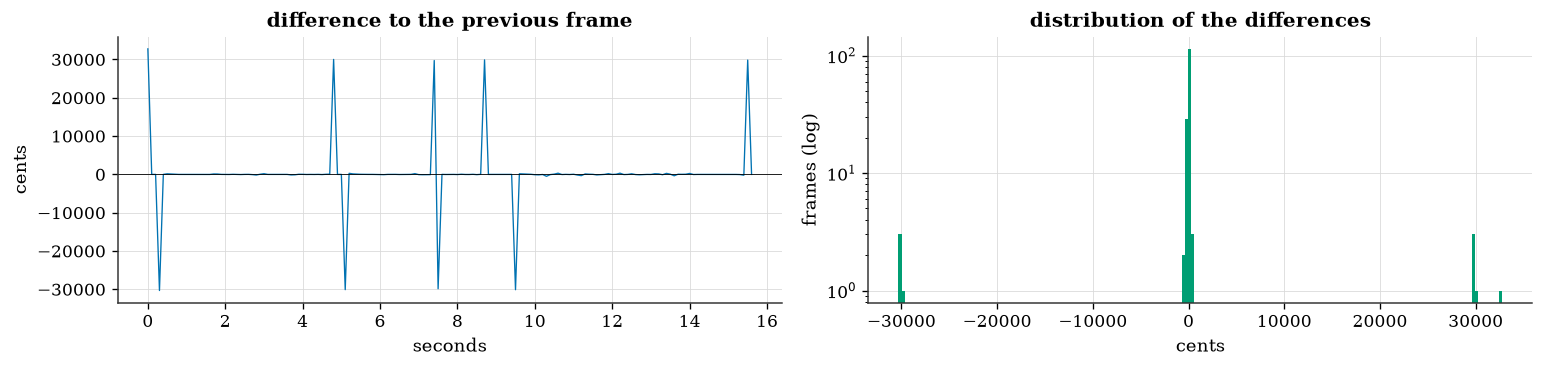

In [5]:
diffs = differences(samples)
bits = samples.view(np.uint16).astype(np.int64)
wrapped = np.diff(bits) % 65536
numpy_delta = np.where(wrapped > 32768, wrapped - 65536, wrapped)

print(f"{'frame':>5}  {'rounded':>7}  {'difference':>10}")
for frame in range(window.start, window.stop):
    print(f"{frame:5d}  {samples[frame]:7d}  {diffs[frame]:10d}")

magnitude = np.abs(diffs)
print()
print(f"median |difference|: {np.median(magnitude):.0f} cents")
print(f"{(magnitude <= 10).mean():.1%} of frames move ten cents or less")
print(f"{(magnitude > 1000).sum()} frames jump over a thousand cents: a voicing edge")
print("first frame kept, the rest equal the wrapped difference:", np.array_equal(diffs[1:], numpy_delta))
print("cumulating the differences rebuilds the cents:", np.array_equal(cumulate(diffs), samples))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].plot(seconds, diffs, lw=0.8, color=PALETTE[0])
axes[0].axhline(0, lw=0.5, color="black")
axes[0].set_title("difference to the previous frame")
axes[0].set_xlabel("seconds")
axes[0].set_ylabel("cents")

axes[1].hist(diffs, bins=200, log=True, color=PALETTE[2])
axes[1].set_title("distribution of the differences")
axes[1].set_xlabel("cents")
axes[1].set_ylabel("frames (log)")
plt.tight_layout()

## Zigzag

Half the differences are negative, and a sign bit would tax every small one of them. Fold both halves onto the non-negative axis:

$$z = \begin{cases} 2d, & d \ge 0 \\ -2d - 1, & d < 0 \end{cases}$$

so $2 \mapsto 4$ and $-3 \mapsto 5$: magnitude in, magnitude out, the sign carried by the parity of the result rather than costing a bit of its own. The fold is a bijection from the signed range onto $[0, 2^{16})$, undone by

$$d = (-1)^{z \bmod 2} \left\lceil \frac{z}{2} \right\rceil$$

frame  difference    folded
   77         -20        39
   78         -10        19
   79           0         0
   80         -35        69
   81          50       100
   82         -15        29
   83         -20        39
   84          30        60
   85         -60       119
   86          25        50
   87       29899     59798
   88           0         0

protobuf ZigZagEncode folds the same way: True
ZigZagDecode undoes it: True
68.8% of the folded values sit below 128 — a single byte each


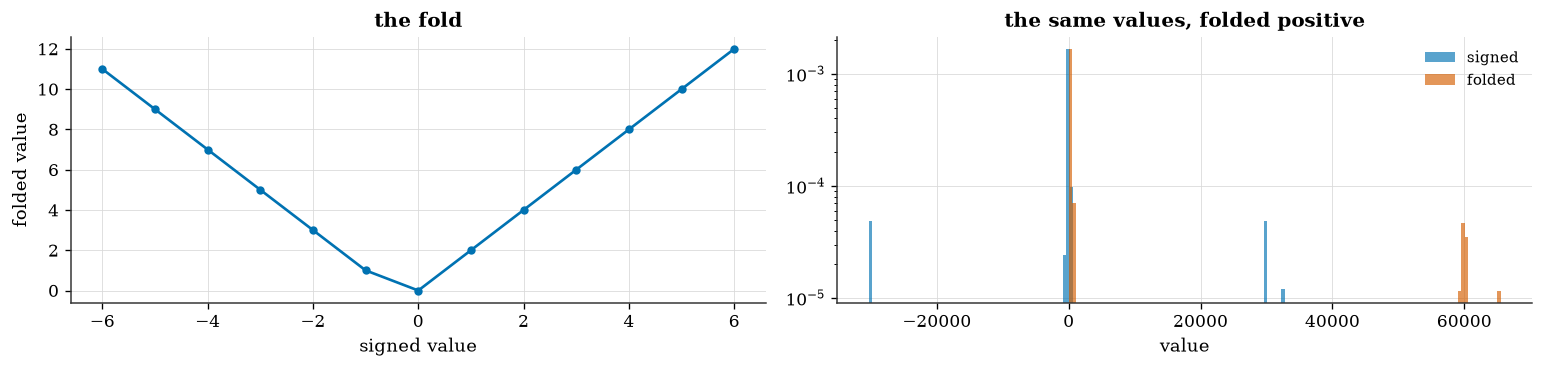

In [6]:
zz = zigzag(diffs)
protobuf_zz = np.array([ZigZagEncode(int(v)) for v in diffs.tolist()], dtype=np.uint64)
protobuf_back = np.array([ZigZagDecode(int(v)) for v in zz.tolist()], dtype=np.int64)

print(f"{'frame':>5}  {'difference':>10}  {'folded':>8}")
for frame in range(window.start, window.stop):
    print(f"{frame:5d}  {diffs[frame]:10d}  {zz[frame]:8d}")

print()
print("protobuf ZigZagEncode folds the same way:", np.array_equal(zz, protobuf_zz))
print("ZigZagDecode undoes it:", np.array_equal(protobuf_back, diffs))
print(f"{(zz <= 127).mean():.1%} of the folded values sit below 128 — a single byte each")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axis = np.arange(-6, 7)
axes[0].plot(axis, [ZigZagEncode(int(v)) for v in axis], "o-", color=PALETTE[0])
axes[0].set_title("the fold")
axes[0].set_xlabel("signed value")
axes[0].set_ylabel("folded value")

axes[1].hist(diffs, bins=120, log=True, density=True, alpha=0.65,
             label="signed", color=PALETTE[0])
axes[1].hist(zz, bins=120, log=True, density=True, alpha=0.65,
             label="folded", color=PALETTE[1])
axes[1].set_title("the same values, folded positive")
axes[1].set_xlabel("value")
axes[1].legend()
plt.tight_layout()

## Variable-length integers

Small numbers are mostly leading zeros, so write only the digits that carry weight:

$$z = \sum_{k \ge 0} b_k\, 2^{7k}, \qquad b_k \in [0, 128)$$

seven bits a byte, least significant group first, every byte but the last flagged as unfinished. A difference that folds below 128 costs exactly one byte, a voicing edge three. The two bytes a frame become well under one — and the frame boundaries go with them, the stream now being only the values back to back, which is why the frame count has to travel ahead of it.

frame   folded   bytes
   77       39   27
   78       19   13
   79        0   00
   80       69   45
   81      100   64
   82       29   1d
   83       39   27
   84       60   3c
   85      119   77
   86       50   32
   87    59798   96 d3 03
   88        0   00

protobuf's wire format produces the same bytes: True
1 byte(s):  68.8% of the values
2 byte(s):  25.5% of the values
3 byte(s):   5.7% of the values
total: 215 bytes for 157 frames — 1.37 a frame, against 314 bytes at two a frame


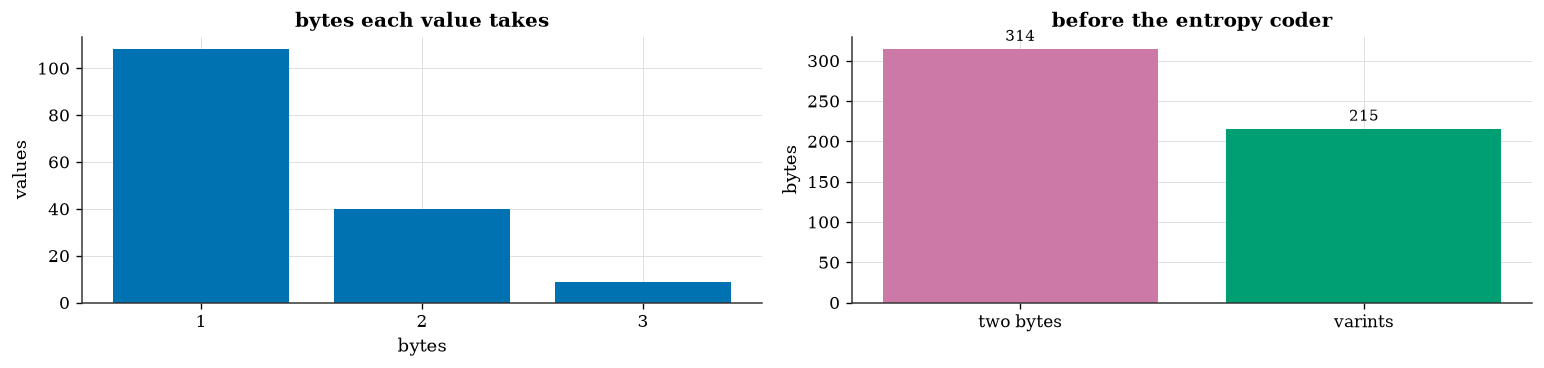

In [7]:
packed = encode_varints(zz)
protobuf_packed = b"".join(_VarintBytes(int(v)) for v in zz.tolist())

print(f"{'frame':>5}  {'folded':>7}   bytes")
for frame in range(window.start, window.stop):
    print(f"{frame:5d}  {zz[frame]:7d}   {_VarintBytes(int(zz[frame])).hex(' ')}")

widths = np.array([len(_VarintBytes(int(v))) for v in zz.tolist()])
print()
print("protobuf's wire format produces the same bytes:", protobuf_packed == packed)
for width in (1, 2, 3):
    print(f"{width} byte(s): {(widths == width).mean():6.1%} of the values")
print(f"total: {len(packed)} bytes for {samples.size} frames — "
      f"{len(packed) / samples.size:.2f} a frame, against {samples.nbytes} bytes at two a frame")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
axes[0].bar(["1", "2", "3"], [int(np.sum(widths == w)) for w in (1, 2, 3)],
            color=PALETTE[0])
axes[0].set_title("bytes each value takes")
axes[0].set_xlabel("bytes")
axes[0].set_ylabel("values")

bars = axes[1].bar(["two bytes", "varints"], [samples.nbytes, len(packed)],
                   color=[PALETTE[3], PALETTE[2]])
axes[1].bar_label(bars, fmt="%d", padding=3, fontsize=9)
axes[1].set_title("before the entropy coder")
axes[1].set_ylabel("bytes")
plt.tight_layout()

## Deflate

The stream still repeats itself — a long voiced passage writes the same small bytes over and over. Deflate replaces each repeated stretch with a *back-reference*: where it starts, counted back into the stream, and how long it runs, instead of the bytes themselves. What is left — single bytes and back-references — is then coded by frequency: common symbols few bits, rare ones more, the arithmetic Huffman's algorithm applies to any alphabet.

The result is wrapped for storage: a two-byte header saying how it was made, the blocks themselves, and the Adler-32 checksum of the input at the end. The level is only how hard the search for repeats tries; every level appears below, and the contour is packed at the level the code sets.

215 bytes of values deflate to 218 bytes (101.4%)
head: 78 da 1d ce 21 4c c3 40 14 87 f1 ff 7b ef 16 d2 67 af f6 ce 76 b6 b3 9c ed ec cd 32 4b ed f4 90
header: CMF 0x78 is method 8 in a 32768-byte window, FLG 0xda
trailer is the adler32 of the input: True
level 0:    226 bytes (105.1% of the values)
level 1:    218 bytes (101.4% of the values)
level 2:    218 bytes (101.4% of the values)
level 3:    218 bytes (101.4% of the values)
level 4:    218 bytes (101.4% of the values)
level 5:    218 bytes (101.4% of the values)
level 6:    218 bytes (101.4% of the values)
level 7:    218 bytes (101.4% of the values)
level 8:    218 bytes (101.4% of the values)
level 9:    218 bytes (101.4% of the values)  <- packed at this level


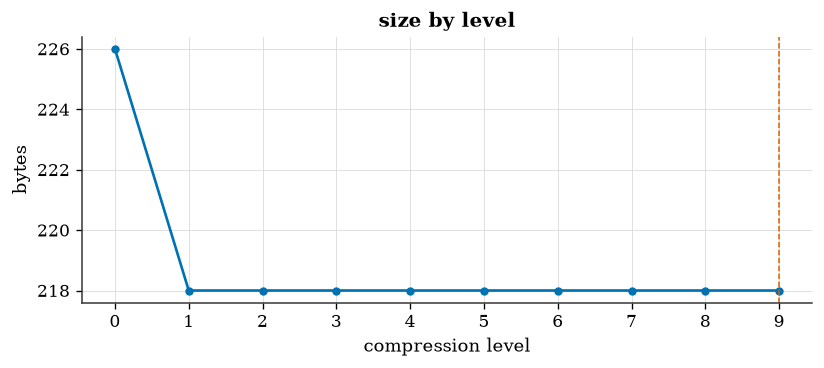

In [8]:
level_sizes = {level: len(zlib.compress(packed, level)) for level in range(10)}
payload = zlib.compress(packed, level=9)

print(f"{len(packed)} bytes of values deflate to {len(payload)} bytes "
      f"({len(payload) / len(packed):.1%})")
print("head:", payload[:32].hex(" "))
cmf, flg = payload[0], payload[1]
print(f"header: CMF {cmf:#04x} is method {cmf & 0x0f} in a {1 << ((cmf >> 4) + 8)}-byte window, "
      f"FLG {flg:#04x}")
print("trailer is the adler32 of the input:",
      payload[-4:] == zlib.adler32(packed).to_bytes(4, "big"))

for level, size in level_sizes.items():
    note = "  <- packed at this level" if level == 9 else ""
    print(f"level {level}: {size:6d} bytes ({size / len(packed):6.1%} of the values){note}")

plt.figure(figsize=(7, 3.2))
plt.plot(list(level_sizes), [level_sizes[level] for level in level_sizes],
         "o-", color=PALETTE[0])
plt.axvline(9, lw=0.9, ls="--", color=PALETTE[1])
plt.xticks(range(10))
plt.xlabel("compression level")
plt.ylabel("bytes")
plt.title("size by level")
plt.tight_layout()

## The blob

Thirteen bytes of framing go in front of the stream — the format's tag, the version, the number of frames, and the spacing of the grid in microseconds:

`SFPT | version | frames | hop | deflated stream`

then the stream itself. The sizes below are every stage of this notebook, side by side.

In [9]:
blob = encode_contour(contour, hop_seconds)
magic, version, frames, hop_microseconds = HEADER.unpack_from(blob, 0)

print("header:", magic.decode(), "version", version, frames, "frames,",
      hop_microseconds, "microseconds a frame")
print("head of the blob:", blob[:32].hex(" "))
print("payload is the stream from the cell above:", blob[HEADER.size:] == payload)

stages = [
    ("contour", contour.nbytes),
    ("whole cents", samples.nbytes),
    ("differences", diffs.size * 2),
    ("folded values as varints", len(packed)),
    ("deflated stream", len(payload)),
    ("blob with header", len(blob)),
]

print()
for name, size in stages:
    print(f"{name:26s} {size:7d} bytes  {size / samples.size:5.2f} a frame  "
          f"{size / contour.nbytes:6.1%} of the contour")

print()
print(f"{contour.nbytes / samples.size:g} -> {len(blob) / samples.size:.2f} bytes a frame overall")

header: SFPT version 2 157 frames, 100000 microseconds a frame
head of the blob: 53 46 50 54 02 9d 00 00 00 a0 86 01 00 78 da 1d ce 21 4c c3 40 14 87 f1 ff 7b ef 16 d2 67 af f6
payload is the stream from the cell above: True

contour                       1256 bytes   8.00 a frame  100.0% of the contour
whole cents                    314 bytes   2.00 a frame   25.0% of the contour
differences                    314 bytes   2.00 a frame   25.0% of the contour
folded values as varints       215 bytes   1.37 a frame   17.1% of the contour
deflated stream                218 bytes   1.39 a frame   17.4% of the contour
blob with header               231 bytes   1.47 a frame   18.4% of the contour

8 -> 1.47 bytes a frame overall


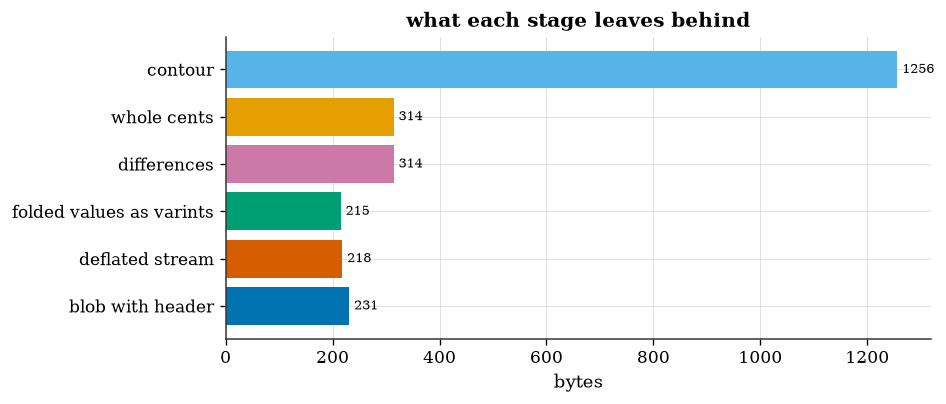

In [10]:
labels = [name for name, _ in stages]
sizes = [size for _, size in stages]

plt.figure(figsize=(8, 3.5))
bars = plt.barh(labels[::-1], sizes[::-1], color=PALETTE[:len(labels)])
plt.bar_label(bars, fmt="%d", padding=3, fontsize=8)
plt.xlabel("bytes")
plt.title("what each stage leaves behind")
plt.tight_layout()

## Round trip

Each stage is undone by its inverse: inflate the stream, regroup seven bits at a time into values, apply the fold's inverse, cumulate modulo $2^{16}$, read the cents back — and the frames reserved for no pitch come back as `nan`, in place. Every stage but the rounding reverses exactly, so the contour that comes out differs from the one that went in only by $|e_i| \le \tfrac12$ cent.

In [11]:
rebuilt, hop_back = decode_contour(blob)
inflated = zlib.decompress(blob[HEADER.size:])
zz_back = decode_varints(inflated, frames)
diffs_back = unzigzag(zz_back)
samples_back = cumulate(diffs_back)
quantised_back = dequantise(samples_back)

checks = [
    ("inflate", inflated == packed),
    ("varint decode", np.array_equal(zz_back, zz)),
    ("fold", np.array_equal(diffs_back, diffs)),
    ("cumulate", np.array_equal(samples_back, samples)),
    ("dequantise", np.array_equal(quantised_back, quantised)),
    ("contour", np.array_equal(rebuilt, quantised, equal_nan=True)),
]
for name, ok in checks:
    print(f"{name:15s} identical: {ok}")

print()
print(f"{'frame':>5}  {'cents':>10}  {'rebuilt':>9}  {'residual':>9}")
for frame in range(window.start, window.stop):
    print(f"{frame:5d}  {contour[frame]:10.3f}  {rebuilt[frame]:9.3f}  "
          f"{rebuilt[frame] - contour[frame]:+9.3f}")

rounding = np.abs(rebuilt - contour)
print()
print(f"only the rounding survives: max {np.nanmax(rounding):.3f} cents, "
      f"mean {np.nanmean(rounding):.3f} cents")
print("unvoiced frames kept:", np.array_equal(np.isnan(rebuilt), np.isnan(contour)))
print("hop:", hop_back, "seconds")

inflate         identical: True
varint decode   identical: True
fold            identical: True
cumulate        identical: True
dequantise      identical: False
contour         identical: True

frame       cents    rebuilt   residual
   77    2903.682   2904.000     +0.318
   78    2893.682   2894.000     +0.318
   79    2893.682   2894.000     +0.318
   80    2858.682   2859.000     +0.318
   81    2908.682   2909.000     +0.318
   82    2893.682   2894.000     +0.318
   83    2873.682   2874.000     +0.318
   84    2903.682   2904.000     +0.318
   85    2843.682   2844.000     +0.318
   86    2868.682   2869.000     +0.318
   87         nan        nan       +nan
   88         nan        nan       +nan

only the rounding survives: max 0.318 cents, mean 0.318 cents
unvoiced frames kept: True
hop: 0.1 seconds


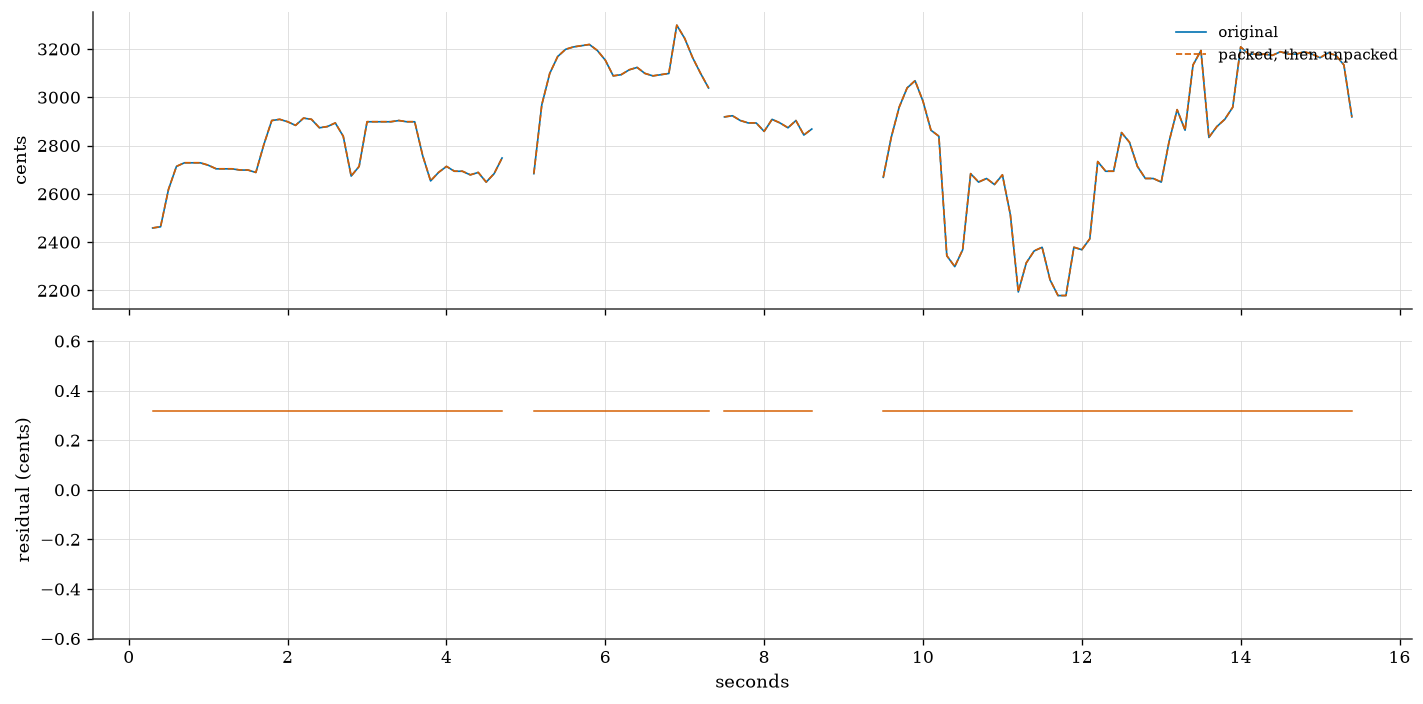

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(seconds, contour, lw=1, label="original")
axes[0].plot(seconds, rebuilt, lw=1, ls="--", label="packed, then unpacked")
axes[0].set_ylabel("cents")
axes[0].legend(loc="upper right")

axes[1].plot(seconds, rebuilt - contour, lw=0.9, color=PALETTE[1])
axes[1].axhline(0, lw=0.5, color="black")
axes[1].set_ylim(-0.6, 0.6)
axes[1].set_ylabel("residual (cents)")
axes[1].set_xlabel("seconds")
plt.tight_layout()